/tmp/ipykernel_472385/2499408358.py:164: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


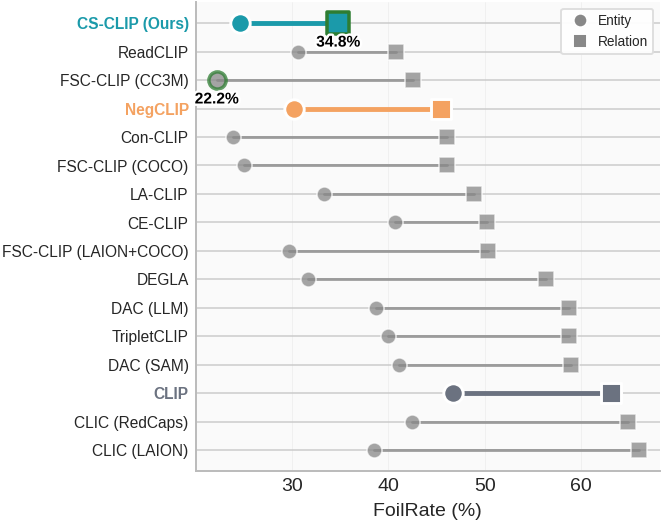

In [1]:
import matplotlib.patheffects as pe
import tueplots
from tueplots import figsizes
import matplotlib.pyplot as plt
import json
import numpy as np

# Use consistent modern style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update(figsizes.icml2024_full())

# Load data
path = "../jsons/ht_entity_vs_relations.json"
with open(path, "r") as f:
    data = json.load(f)

rows = data["models"]

# Sort by relation FoilRate
rows = sorted(rows, key=lambda r: r["Rel_FoilRate"])

models = [r["model"] for r in rows]
comp = np.array([r["Comp_FoilRate"] for r in rows], dtype=float)
rel = np.array([r["Rel_FoilRate"] for r in rows], dtype=float)

y = np.arange(len(models))

# Key models with distinct styling (consistent with scatter plot)
KEY_COLORS = {
    "CS-CLIP": "#1B9AAA",   # Teal
    "NegCLIP": "#F4A261",   # Coral
    "CLIP": "#6B7280",      # Slate gray
}

# Find best performers for entity and relation (lowest FoilRate)
best_entity_idx = np.argmin(comp)
best_relation_idx = np.argmin(rel)

# Highlight color for best performers
BEST_COLOR = "#2E7D32"  # Green for best

# Compact figure
fig, ax = plt.subplots(figsize=(5, 4), dpi=140)

# Draw connecting lines and endpoints
for i, m in enumerate(models):
    is_key = m in KEY_COLORS
    is_best_entity = (i == best_entity_idx)
    is_best_relation = (i == best_relation_idx)
    
    # Default color for non-key models (visible gray)
    line_color = KEY_COLORS.get(m, "#888888")
    
    # Line thickness and alpha
    lw = 2.5 if is_key else 1.5
    alpha = 1.0 if is_key else 0.75
    
    # Connecting line
    ax.plot([comp[i], rel[i]], [y[i], y[i]], 
            color=line_color, linewidth=lw, alpha=alpha, zorder=2 if is_key else 1)
    
    # Marker sizes
    s = 100 if is_key else 60
    edge_lw = 1.5 if is_key else 0.8
    edge_color = "white"
    
    # Entity endpoint (circle) - highlight best
    entity_edge = BEST_COLOR if is_best_entity else edge_color
    entity_lw = 1.8 if is_best_entity else edge_lw
    entity_s = s * 1.3 if is_best_entity else s
    ax.scatter(comp[i], y[i], s=entity_s, marker="o", 
               c=line_color, edgecolor=entity_edge, linewidth=entity_lw, 
               alpha=alpha, zorder=4 if is_best_entity else (3 if is_key else 2))
    
    # Relation endpoint (square) - highlight best
    rel_edge = BEST_COLOR if is_best_relation else edge_color
    rel_lw = 1.8 if is_best_relation else edge_lw
    rel_s = s * 1.3 if is_best_relation else s
    ax.scatter(rel[i], y[i], s=rel_s, marker="s", 
               c=line_color, edgecolor=rel_edge, linewidth=rel_lw,
               alpha=alpha, zorder=4 if is_best_relation else (3 if is_key else 2))

# Add text labels for best performers - position to avoid overlaps
# Entity best label: position below the point if it's near top, otherwise above
entity_y_offset = -12 if best_entity_idx < 3 else 10
ax.annotate(
    f"{comp[best_entity_idx]:.1f}%",
    (comp[best_entity_idx], y[best_entity_idx]),
    textcoords="offset points",
    xytext=(0, entity_y_offset),
    fontsize=8,
    fontweight="bold",
    color="black",
    ha="center",
    zorder=100,
    path_effects=[pe.withStroke(linewidth=2.5, foreground="white")]
)

# Relation best label: position above the point
ax.annotate(
    f"{rel[best_relation_idx]:.1f}%",
    (rel[best_relation_idx], y[best_relation_idx]),
    textcoords="offset points",
    xytext=(0, -12),
    fontsize=8,
    fontweight="bold",
    color="black",
    ha="center",
    zorder=100,
    path_effects=[pe.withStroke(linewidth=2.5, foreground="white")]
)

# Y-axis labels with highlighting
ax.set_yticks(y)
ylabels = []
for m in models:
    if m == "CS-CLIP":
        ylabels.append("CS-CLIP (Ours)")
    else:
        ylabels.append(m)
ax.set_yticklabels(ylabels, fontsize=8)

# Color the key model labels
for i, m in enumerate(models):
    if m in KEY_COLORS:
        ax.get_yticklabels()[i].set_color(KEY_COLORS[m])
        ax.get_yticklabels()[i].set_fontweight("bold")

# X-axis label
ax.set_xlabel("FoilRate (%)", fontsize=10)

# Legend for markers (compact, top-right)
legend_handles = [
    plt.Line2D([0], [0], marker="o", linestyle="", markersize=7,
               markerfacecolor="#888888", markeredgecolor="white",
               markeredgewidth=1, label="Entity"),
    plt.Line2D([0], [0], marker="s", linestyle="", markersize=7,
               markerfacecolor="#888888", markeredgecolor="white",
               markeredgewidth=1, label="Relation"),
]
ax.legend(
    handles=legend_handles,
    loc="upper right",
    frameon=True,
    framealpha=0.95,
    edgecolor="#dddddd",
    fontsize=7,
    handletextpad=0.3,
    borderpad=0.4
)

# Style - consistent with scatter plot
ax.set_facecolor("#fafafa")
ax.grid(True, axis="x", alpha=0.25, linestyle="-", linewidth=0.4, color="#cccccc")
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#bbbbbb")
ax.spines["bottom"].set_color("#bbbbbb")

# Invert y-axis so best (lowest FoilRate) is at top
ax.invert_yaxis()

plt.tight_layout()
plt.savefig("../paper_figures/dumbbell_plot.pdf", bbox_inches="tight", dpi=150)
plt.show()